<a href="https://colab.research.google.com/github/SAR-DINE-procom/traitement/blob/master/sar_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup du notebook
Les prochaines cellules permettent de mettre en place le notebook pour réaliser la simulation de données SAR.

Veuillez lancer la première cellule, cela permettra de récupérer le script d'installation de matlab.


In [ ]:
from google.colab import userdata
token_github = userdata.get('github')
# !git clone "https://{token_github}@github.com/SAR-DINE-procom/traitement.git"
# # test 2
# !wget --header 'Authorization: token {token_github}' -O install-matlab.sh https://github.com/SAR-DINE-procom/traitement/raw/master/install_matlab.sh
!wget https://gist.githubusercontent.com/WW9kYQ/c3943f343ba77dd1d1fa468b71ef68ef/raw/54bfb560771df556861db14e5690a8b02f2d0987/install-matlab.sh
!chmod +x install-matlab.sh

--2025-11-12 21:41:56--  https://gist.githubusercontent.com/WW9kYQ/c3943f343ba77dd1d1fa468b71ef68ef/raw/54bfb560771df556861db14e5690a8b02f2d0987/install-matlab.sh
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 851 [text/plain]
Saving to: ‘install-matlab.sh’

install-matlab.sh   100%[===================>]     851  --.-KB/s    in 0s      

2025-11-12 21:41:56 (33.6 MB/s) - ‘install-matlab.sh’ saved [851/851]



Dirigez-vous maintenant dans l'onglet terminal, et exécutez la commande suivante :
`./install-matlab.sh`

Une fois que vous avez le message vous indiquant que le service de matlab est bien démarré, copiez le token du lien et conserver le pour la session.

Lancez ensuite la cellule suivante et cliquez sur le lien `https://localhost:3000/` qui apparait. Renseignez le token et authentifiez vous.

Patientez le temps que matlab démarre.

In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(3000, path='/')

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

Une fois matlab démarré, exécutez la cellule ci-dessous.

In [ ]:
import matlab.engine

e = matlab.engine.start_matlab("-licmode onlinelicensing")

Votre environnement de développement Python est maintenant relié à matlab via son kernel, pour y faire appel, utilisez `e.[fonction_matlab]`.

In [ ]:
# IMPORT DES LIBRAIRIES
import math
import numpy as np
import matplotlib.pyplot as plt

Simulation terminée.


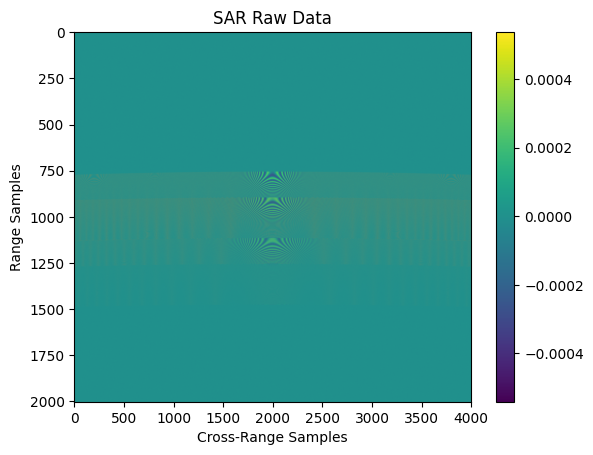

In [ ]:

# config radar et paramètres de base
c = e.physconst('LightSpeed')
fc = 4.0e9
rangeResolution = 3.0
crossRangeResolution = 3.
bw = c/(2*rangeResolution)
prf = 1000.0
aperture = 4.0
tpd = 3.0*math.pow(10,-6)
fs = 120.0*math.pow(10,6)

waveform = e.phased.LinearFMWaveform('SampleRate',fs, 'PulseWidth', tpd, 'PRF', prf, 'SweepBandwidth', bw);

speed = 100.0
flightDuration = 4
pos = np.array([[0], [-200], [500]], dtype=float)
vel = np.array([[0], [speed], [0]], dtype=float)

radarPlatform = e.phased.Platform('InitialPosition', pos,'Velocity', vel,nargout=1)

slowTime = 1/prf
numpulses = flightDuration/slowTime +1
maxRange = 2500
truncrangesamples = e.ceil((2*maxRange/c)*fs)
fastTime = np.arange(truncrangesamples) / fs
RC = 1000

freq_range = matlab.double([1e9, 6e9])
antenna = e.phased.CosineAntennaElement('FrequencyRange', freq_range, nargout=1)

antennaGain = e.aperture2gain(aperture, c / fc, nargout=1)

transmitter = e.phased.Transmitter('PeakPower', 50e3, 'Gain', antennaGain, nargout=1)

radiator = e.phased.Radiator('Sensor', antenna, 'OperatingFrequency', fc, 'PropagationSpeed', c, nargout=1)

collector = e.phased.Collector('Sensor', antenna, 'PropagationSpeed', c, 'OperatingFrequency', fc, nargout=1)

receiver = e.phased.ReceiverPreamp('SampleRate', fs, 'NoiseFigure', 30.0, nargout=1)

channel = e.phased.FreeSpace('PropagationSpeed', c, 'OperatingFrequency', fc, 'SampleRate', fs, 'TwoWayPropagation', True, nargout=1)

# Config scene
targetpos_np = np.array([[800, 0, 0],
                         [1000, 0, 0],
                         [1300, 0, 0]], dtype=float).T
# targetpos_np est maintenant :
# [[ 800. 1000. 1300.]
#  [   0.    0.    0.]
#  [   0.    0.    0.]]

targetvel_np = np.zeros((3, 3), dtype=float)

mean_rcs = matlab.double([1.0, 1.0, 1.0])
target = e.phased.RadarTarget('OperatingFrequency', fc, 'MeanRCS', mean_rcs, nargout=1)

pointTargets = e.phased.Platform('InitialPosition', targetpos_np, 'Velocity', targetvel_np, nargout=1)

num_targets = targetpos_np.shape[1]
refangle = np.zeros(num_targets)

rxsig = np.zeros((int(truncrangesamples), int(numpulses)), dtype=np.complex128)

for ii in range(int(numpulses)):
    radarpos, radarvel = e.step(radarPlatform, slowTime, nargout=2)
    targetpos, targetvel = e.step(pointTargets, slowTime, nargout=2)

    targetRange, targetAngle = e.rangeangle(targetpos, radarpos, nargout=2)

    sig = e.step(waveform, nargout=1)

    sig = sig[0:int(truncrangesamples)]

    sig = e.step(transmitter, sig, nargout=1)

    targetAngle_np = np.array(targetAngle)
    targetAngle_np[0, :] = refangle
    targetAngle_mod = matlab.double(targetAngle_np.tolist())

    sig = e.step(radiator, sig, targetAngle_mod, nargout=1)

    sig = e.step(channel, sig, radarpos, targetpos, radarvel, targetvel, nargout=1)

    sig = e.step(target, sig, nargout=1)

    sig = e.step(collector, sig, targetAngle_mod, nargout=1)

    sig_received = e.step(receiver, sig, nargout=1)

    rxsig[:, ii] = np.array(sig_received).squeeze()

print("Simulation terminée.")

# Sauvegarde données :
np.save('raw_data.npy', rxsig)

# --- Affichage (avec Matplotlib) ---

# figure(1);
plt.figure(1)
plt.imshow(np.real(rxsig), aspect='auto', origin='upper')
plt.colorbar()
plt.title('SAR Raw Data')
plt.xlabel('Cross-Range Samples')
plt.ylabel('Range Samples')
plt.show()